In [81]:
# imports
import os
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [82]:
# This function takes an image name and returns the data as an ndarray
def imagedata(name):
    image = cv2.imread(name, cv2.IMREAD_GRAYSCALE)
    return image

In [83]:
# class structure for nn
class Network(nn.Module):
    # making of network
    def __init__(self):
        super().__init__() # try experimenting with different layer combinations for better results
        self.fc1 = nn.Linear(784,512)
        self.fc2 = nn.Linear(512,128)
        self.fc3 = nn.Linear(128,64)
        self.output = nn.Linear(64,10)  
    # feedforward process
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.output(x)
        return x

In [87]:
# Prelims

# Gets all image filenames and store them in filenames
directory = './Handwritten-Digits-Spring-2026/digits/'
filenames = os.listdir(directory)

# Define variables and model
epochs = 3
r = 0.001
m = 0.01
model = Network()
optimizer = torch.optim.SGD(model.parameters(), lr=r, momentum=m)

# Store loss for each step (for plotting later)
logLoss = []

In [88]:
# Main loop
for epoch in range(epochs):
    for i in range(len(filenames)):
        # Skip
        if filenames[i] == ".ipynb_checkpoints":
            continue
        # Get file data
        x = imagedata(directory+filenames[i])
        x = torch.tensor(x, dtype=torch.float32)
        x = x.view(1, -1)
        # Skip
        if x.shape != (1, 784):
            continue
        # Zero the weights
        optimizer.zero_grad()
        # Feed the model the data
        outputs = model(x)
        # Get target
        num = int(filenames[i][0])
        target = torch.tensor([num], dtype=torch.long)
        # Get loss
        criterion = nn.CrossEntropyLoss()
        loss = criterion(outputs, target)
        logLoss.append(loss.item()) # can be made smoother (noise reduction)
        # Update weights with gradient
        loss.backward()
        optimizer.step()
    # Validation step (needs implimentation)

libpng warning: iCCP: profile 'ICC Profile': 'RGB ': RGB color space not permitted on grayscale PNG
libpng warning: iCCP: profile 'ICC Profile': 'RGB ': RGB color space not permitted on grayscale PNG
libpng warning: iCCP: profile 'ICC Profile': 'RGB ': RGB color space not permitted on grayscale PNG
libpng warning: iCCP: profile 'ICC Profile': 'RGB ': RGB color space not permitted on grayscale PNG
libpng warning: iCCP: profile 'ICC Profile': 'RGB ': RGB color space not permitted on grayscale PNG
libpng warning: iCCP: profile 'ICC Profile': 'RGB ': RGB color space not permitted on grayscale PNG
libpng warning: iCCP: profile 'ICC Profile': 'RGB ': RGB color space not permitted on grayscale PNG
libpng warning: iCCP: profile 'ICC Profile': 'RGB ': RGB color space not permitted on grayscale PNG
libpng warning: iCCP: profile 'ICC Profile': 'RGB ': RGB color space not permitted on grayscale PNG
libpng warning: iCCP: profile 'ICC Profile': 'RGB ': RGB color space not permitted on grayscale PNG


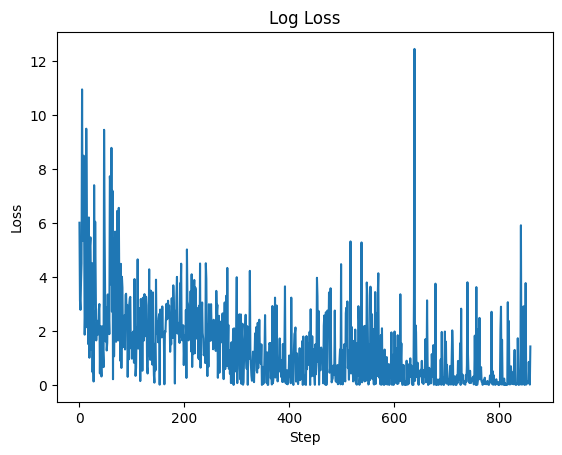

In [89]:
# Plot LogLoss
plt.plot(logLoss)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Log Loss")
plt.show()